# 📊 Fase 3: Análisis Exploratorio de Datos (EDA)
En esta fase analizamos las distribuciones, relaciones, correlaciones y características del dataset limpio para entender mejor los patrones de riesgo en salud mental.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

os.makedirs('images', exist_ok=True)

### 1. Cargar Datos Limpios

In [2]:
df = pd.read_csv('cleaned_data.csv')
df.head()

,Edad,Genero,Comunidad_Autonoma,Situacion_Laboral,Historial_Familiar,Estres_Diario,Horas_Sueno,Actividad_Fisica,Apoyo_Social,Consumo_Redes,RISK_LEVEL
0,56,Masculino,Murcia,Empleado,No,7,6.1,Baja,7,3.5,Medio
1,69,Femenino,Andalucía,Empleado,No,4,6.8,Media,6,3.9,Bajo
2,46,Femenino,Madrid,Empleado,Sí,6,8.9,Media,2,5.6,Alto
3,32,Femenino,Andalucía,Empleado,Sí,7,7.9,Alta,3,4.6,Medio
4,60,Masculino,Comunidad Valenciana,Jubilado,Sí,4,7.0,Baja,1,4.7,Alto


### 2. Análisis Univariante
Visualizamos la distribución de la variable objetivo: `RISK_LEVEL`.

C:\Users\VERDUN\AppData\Local\Temp\ipykernel_15440\366669930.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RISK_LEVEL', data=df, order=['Bajo', 'Medio', 'Alto'], palette='viridis')


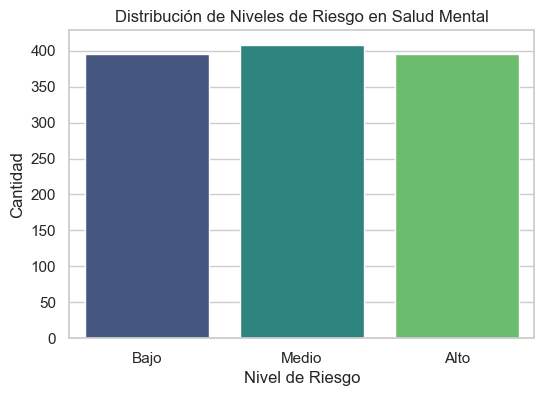

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='RISK_LEVEL', data=df, order=['Bajo', 'Medio', 'Alto'], palette='viridis')
plt.title('Distribución de Niveles de Riesgo en Salud Mental')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad')
plt.savefig('images/distribucion_riesgo.png', bbox_inches='tight')
plt.show()

### 3. Análisis de Variables Numéricas
Revisamos cómo se distribuyen variables clave como estrés diario, horas de sueño, apoyo social y consumo de redes.

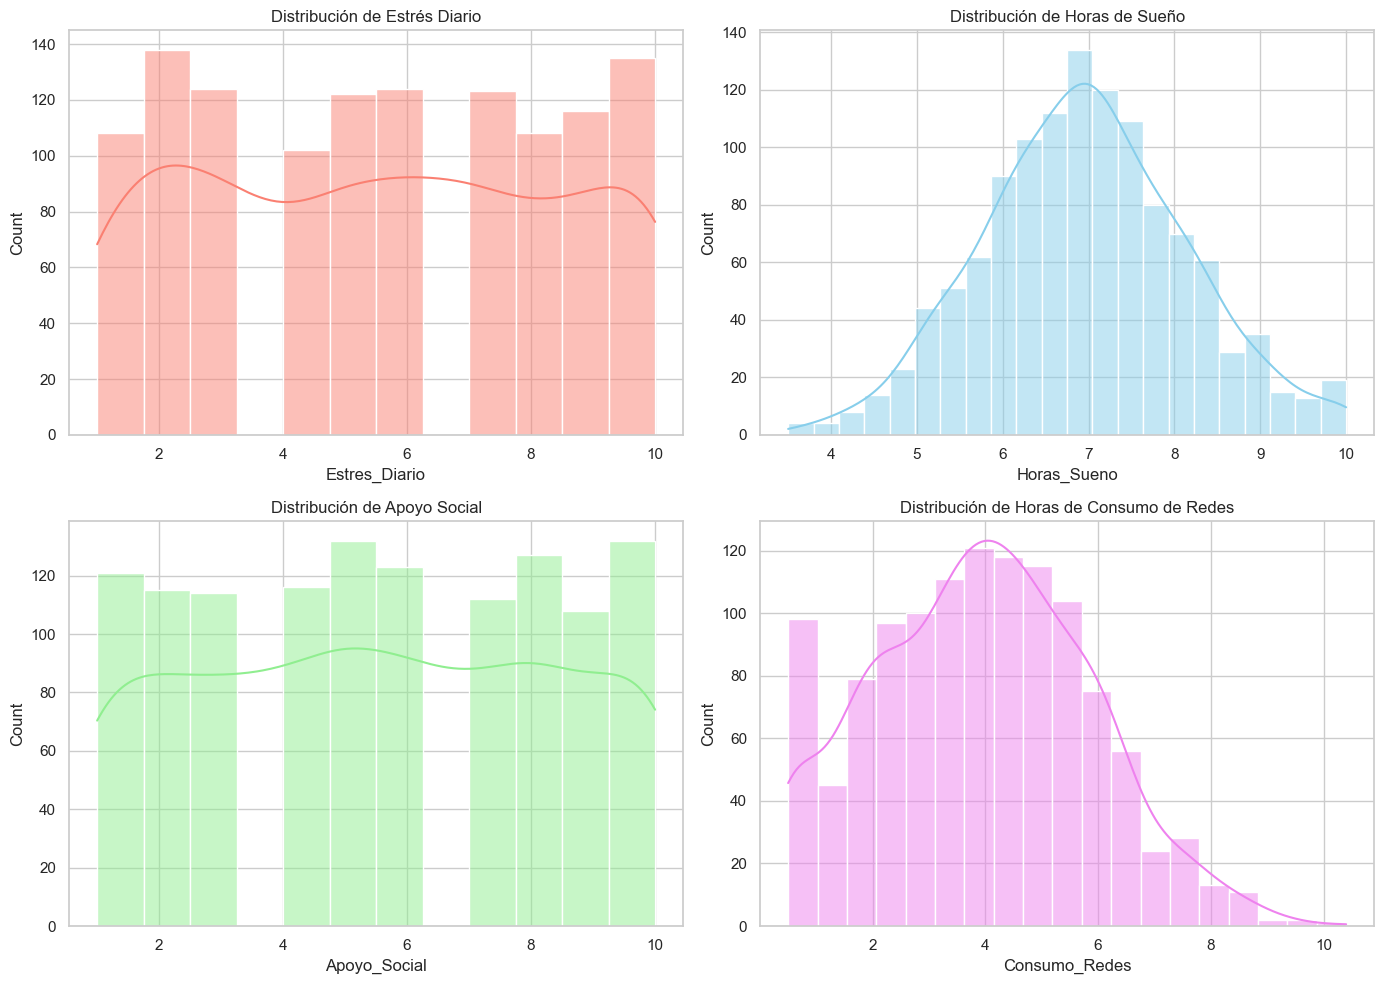

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Estres_Diario'], kde=True, ax=axes[0,0], color='salmon')
axes[0,0].set_title('Distribución de Estrés Diario')

sns.histplot(df['Horas_Sueno'], kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Distribución de Horas de Sueño')

sns.histplot(df['Apoyo_Social'], kde=True, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Distribución de Apoyo Social')

sns.histplot(df['Consumo_Redes'], kde=True, ax=axes[1,1], color='violet')
axes[1,1].set_title('Distribución de Horas de Consumo de Redes')

plt.tight_layout()
plt.savefig('images/distribuciones_numericas.png', bbox_inches='tight')
plt.show()

### 4. Relación de variables con el Nivel de Riesgo
Analicemos cómo varían el estrés y el sueño según el nivel de riesgo.

C:\Users\VERDUN\AppData\Local\Temp\ipykernel_15440\1312782084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RISK_LEVEL', y='Estres_Diario', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[0], palette='coolwarm')
C:\Users\VERDUN\AppData\Local\Temp\ipykernel_15440\1312782084.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RISK_LEVEL', y='Horas_Sueno', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[1], palette='coolwarm')


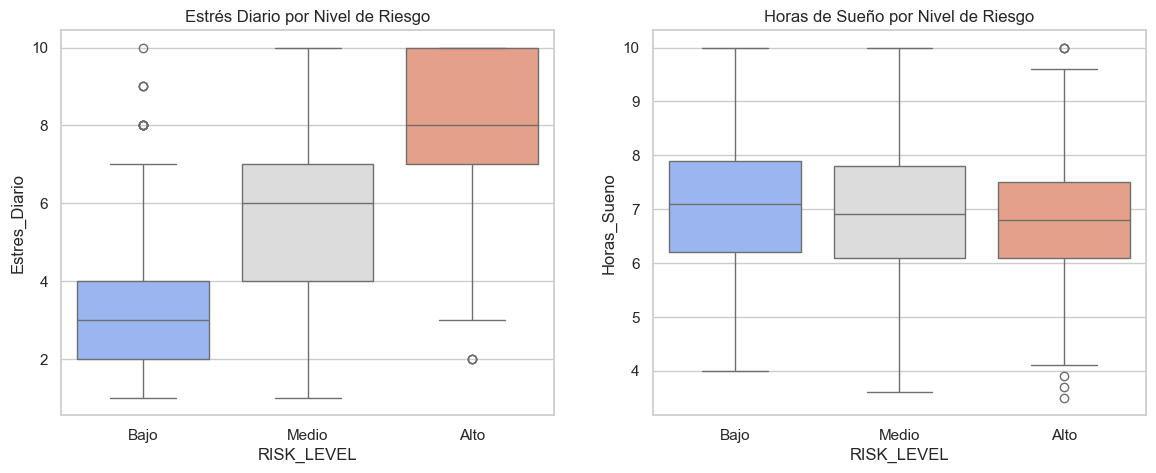

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='RISK_LEVEL', y='Estres_Diario', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[0], palette='coolwarm')
axes[0].set_title('Estrés Diario por Nivel de Riesgo')

sns.boxplot(x='RISK_LEVEL', y='Horas_Sueno', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[1], palette='coolwarm')
axes[1].set_title('Horas de Sueño por Nivel de Riesgo')

plt.savefig('images/boxplots_riesgo.png', bbox_inches='tight')
plt.show()

### 5. Correlación de Variables Numéricas
Vemos la matriz de correlación.

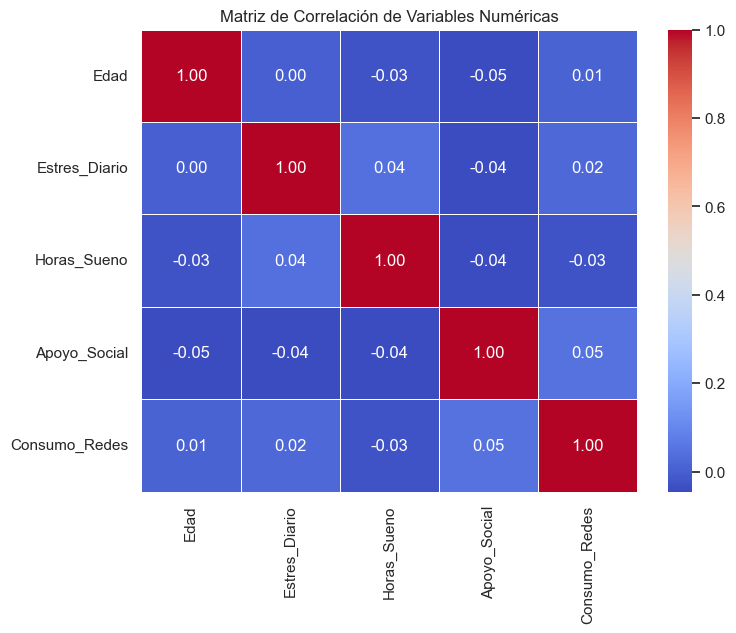

In [6]:
plt.figure(figsize=(8, 6))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.savefig('images/matriz_correlacion.png', bbox_inches='tight')
plt.show()